# H-PPO 主训练入口

该笔记本将逐步整合环境、算法与配置，完成 torchrl + gymnasium 的 H-PPO 训练流程。

## 配置说明

### 历史长度配置 (`history_size`)

**观测空间中的时序信息**由 Simulator 的 `history_stats` 提供：
- **配置位置**: `MACSimulatorConfig.history_size` 或 YAML 中的 `environment.history_size`
- **当前值**: 10 步
- **维度**: `history_stats` = 60 维 (10步 × 6个统计指标)

**6个统计指标**:
1. `requests_cbra` - CBRA请求数
2. `requests_pbra` - PBRA请求数  
3. `collision_ratio_cbra` - CBRA碰撞率
4. `collision_ratio_pbra` - PBRA碰撞率
5. `pending_backoff_cbra` - CBRA待退避数
6. `pending_backoff_pbra` - PBRA待退避数

**注意**: 当前实现中 `history_size` 必须为 10，因为观测空间的 `HISTORY_DIM` 是硬编码的。如需修改，需要同步更新 `mac_simulator.py` 中的限制。

## ⚠️ 注意事项

### Jupyter Notebook 日志重复问题的彻底解决

**问题**: 在 notebook 中多次运行 cell 时，日志会重复输出（2次、3次...）

**原因**: loguru 使用全局 logger，重复运行会累积 handler

**解决方案**（已实施）:
1. 第5个 cell 会调用 `reset_logger()` 清理所有状态
2. `setup_logger()` 现在会检测重复初始化并跳过
3. 如果仍有重复，请按顺序重新执行 cell 5-7

**使用建议**:
- 首次运行: 依次执行所有 cell
- 重新运行: 从第5个 cell 开始重新执行
- 完全清理: 使用 "Restart Kernel" 重启

In [1]:
# 在 Jupyter 环境中重复运行时，先完全重置 logger 状态
# 这样可以避免重复添加 handler 导致日志输出多次
import sys
sys.path.insert(0, '.')  # 确保能导入本地模块

from algo.logger import reset_logger
reset_logger()  # 清理所有旧的 handler 和状态

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
 )
from torchrl.envs import ParallelEnv, SerialEnv, TransformedEnv
from torchrl.envs.libs.gym import GymWrapper
from torchrl.envs.transforms import Compose, DoubleToFloat

In [3]:
CONFIG_PATH = Path("conf/default.yaml")


def _load_yaml_config(path: Path) -> Dict:
    if path.exists():
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle) or {}
            print(f"Loaded configuration from {path}")
            return data
    print(f"Configuration file {path} not found, using defaults.")
    return {}


def _compute_full_cycle_steps(
    sim_config: MACSimulatorConfig, num_slots_per_step: int
) -> int:
    total_length = sum(segment.length for segment in sim_config.segments)
    motion_per_slot = sim_config.motion_per_step / sim_config.slots_per_motion
    displacement_per_step = motion_per_slot * max(1, num_slots_per_step)
    if displacement_per_step <= 0:
        raise ValueError("displacement_per_step must be positive")
    return max(1, math.ceil(total_length / displacement_per_step))


raw_config = _load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251126))
torch.manual_seed(seed)
log_section = raw_config.get("logging", {})
log_file = log_section.get("file", "logs/notebook_training.log")
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized (level={log_level}, file={log_file or '<stderr>'})")
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)
if "motion_per_step" not in env_section:
    env_section["motion_per_step"] = default_simulator_config().motion_per_step


def _override_sim_config(overrides: Dict) -> MACSimulatorConfig:
    base_config = default_simulator_config()
    total = overrides.get("total_preambles")
    split = overrides.get("base_preamble_split")
    if total is not None:
        base_config = replace(base_config, total_preambles=int(total))
    if split is not None:
        if len(split) != 3:
            raise ValueError("base_preamble_split must contain three integers")
        base_config = replace(
            base_config,
            base_preamble_split=tuple(int(x) for x in split),
        )
    noise_scale = overrides.get("noise_scale")
    if noise_scale is not None:
        base_config = replace(base_config, noise_scale=float(noise_scale))
    motion_per_step = overrides.get("motion_per_step")
    if motion_per_step is not None:
        base_config = replace(base_config, motion_per_step=float(motion_per_step))
    # 配置历史长度 (Simulator 层的 history_size)
    # 注意: 由于 HISTORY_DIM 是硬编码的，当前必须保持为 10
    # 如果需要修改，需要同步更新 mac_simulator.py 中的限制
    history_size = overrides.get("history_size", 10)
    if history_size != 10:
        my_logger.warning(
            f"history_size={history_size} requested, but current implementation "
            f"requires history_size=10. Using default value."
        )
        history_size = 10
    base_config = replace(base_config, history_size=int(history_size))
    return base_config


simulator_config = _override_sim_config(env_section)
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))
default_horizon = _compute_full_cycle_steps(simulator_config, num_slots_per_step)
env_config = SatelliteMACEnvConfig(
    num_slots_per_step=num_slots_per_step,
    decision_horizon=80,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)
my_logger.info(f"env_config {env_config}")
my_logger.info(f"Simulator history_size={simulator_config.history_size} (history_stats dim={simulator_config.history_size * 6})")
num_envs = 8  # max(1, int(env_section.get("num_envs", 4)))
env_backend = str(
    env_section.get("env_backend", env_section.get("backend", "parallel"))
).lower()
parallel_collection = bool(env_section.get("parallel_collection", True))
if env_backend not in {"serial", "parallel"}:
    my_logger.warning(f"Unknown env_backend={env_backend}, falling back to 'serial'")
    env_backend = "serial"
if parallel_collection:
    env_backend = "parallel"
train_config = HPPOConfig(
    frames_per_batch=2560,  # int(algo_section.get("frames_per_batch", 1024)),
    mini_batch_size=256,  # int(algo_section.get("mini_batch_size", 128)),
    rollout_epochs=4,  # int(algo_section.get("rollout_epochs", 4)),
    max_iterations=200,  # int(algo_section.get("max_iterations", 100)),
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,  # float(algo_section.get("clip_epsilon", 0.2)),
    entropy_coeff=0.1,  # float(algo_section.get("entropy_coeff", 0.01)),
    actor_lr=3e-4,  # float(algo_section.get("actor_lr", 3e-4)),
    critic_lr=3e-4,  # float(algo_section.get("critic_lr", 3e-4)),
    device=torch.device(algo_section.get("device", "cpu")),
)
my_logger.info(f"train_config {train_config}")
if train_config.frames_per_batch % num_envs != 0:
    my_logger.warning(
        f"frames_per_batch ({train_config.frames_per_batch}) is not divisible by num_envs ({num_envs}); collector will pad the last mini-batch.",
    )
my_logger.info(
    f"Config ready | seed={seed} frames_per_batch={train_config.frames_per_batch} horizon={env_config.decision_horizon} num_envs={num_envs} backend={env_backend} parallel={parallel_collection}",
)

2025-12-02 15:20:21 | INFO     | Logger initialized (level=INFO, file=logs/train.log)


Loaded configuration from conf\default.yaml


2025-12-02 15:20:21 | INFO     | env_config SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.25, cfra_density=0.15000000000000002), RegionTrafficProfile(name='periurban', cbra_density=0.8, pbra_density=3.0, cfra_density=0.2), RegionTrafficProfile(name='urban', cbra_density=85.0, pbra_density=10.0, cfra_density=5.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(24, 24, 16), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.01, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_

## 构建 TorchRL 环境与模块
- 使用 `GymWrapper` + `TransformedEnv` 适配 `SatelliteMACEnv`
- 通过 `build_hppo_modules` 生成混合动作策略与价值网络

In [4]:
def _make_wrapped_env(rank: int = 0, **_: object) -> GymWrapper:
    env_seed = seed + rank if seed is not None else None
    wrapped = build_gym_env(config=deepcopy(env_config))
    wrapped.set_seed(env_seed)
    return wrapped
if num_envs <= 1:
    base_env = _make_wrapped_env(0)
else:
    if env_backend == "parallel":
        base_env = ParallelEnv(num_envs, _make_wrapped_env)
    else:
        base_env = SerialEnv(num_envs, _make_wrapped_env, auto_reset=True)
transforms = Compose(DoubleToFloat())
rl_env = TransformedEnv(base_env, transforms)
rl_env.set_seed(seed)
rl_env.to(train_config.device)
actor, critic = build_hppo_modules(rl_env, feature_dim=128)
actor.to(train_config.device)
critic.to(train_config.device)
obs_shape = rl_env.observation_spec["observation"].shape
my_logger.info(
    f"TorchRL env constructed (observation={obs_shape}, "
    f" num_envs={num_envs}, backend={env_backend}, "
    f"parallel={parallel_collection})",
)
actor, critic

SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.25, cfra_density=0.15000000000000002), RegionTrafficProfile(name='periurban', cbra_density=0.8, pbra_density=3.0, cfra_density=0.2), RegionTrafficProfile(name='urban', cbra_density=85.0, pbra_density=10.0, cfra_density=5.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(24, 24, 16), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.01, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-02 15:20:23 | INFO     | TorchRL env constructed (observation=torch.Size([8, 87]),  num_envs=8, backend=parallel, parallel=True)


(ProbabilisticActor(
     module=ModuleList(
       (0): TensorDictSequential(
           module=ModuleList(
             (0): TensorDictModule(
                 module=_FeatureEncoder(
                   (net): Sequential(
                     (0): Linear(in_features=87, out_features=256, bias=True)
                     (1): ReLU()
                     (2): Linear(in_features=256, out_features=128, bias=True)
                     (3): ReLU()
                   )
                 ),
                 device=cpu,
                 in_keys=['observation'],
                 out_keys=['state_feature'])
             (1): TensorDictModule(
                 module=_PolicyParamExtractor(
                   (cbra_head): Linear(in_features=128, out_features=5, bias=True)
                   (pbra_head): Linear(in_features=128, out_features=5, bias=True)
                   (acb_head): Linear(in_features=128, out_features=2, bias=True)
                 ),
                 device=cpu,
                

## 运行 H-PPO 训练
- 复用 `train_hppo` 并提供 Loguru 回调记录每次迭代指标
- 可通过调整 `train_config` 控制批量尺寸、迭代次数等超参数

In [5]:
metrics_history: list[dict[str, float]] = []
def _log_metrics(*, iteration: int, reward: float, **metrics: float) -> None:
    record = {
        "iteration": iteration,
        "reward": reward,
    }
    for key, value in sorted(metrics.items()):
        try:
            scalar = float(value)
        except (TypeError, ValueError):
            continue
        if key in {"requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra"}:
            clean_value = int(round(scalar))
        elif key.startswith("collision_ratio"):
            clean_value = round(max(0.0, min(scalar, 1.0)), 4)
        else:
            clean_value = scalar
        record[key] = clean_value
    metrics_history.append(record)
    message = [f"iter={iteration:04d}", f"reward={reward:.4f}"]
    for key, value in sorted(record.items()):
        if key in {"iteration", "reward"}:
            continue
        if key in {"requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra"}:
            message.append(f"{key}={int(value)}")
        elif isinstance(value, float):
            message.append(f"{key}={value:.4f}")
        else:
            message.append(f"{key}={value}")
    my_logger.info(" ".join(message))

my_logger.info("Starting notebook PPO run")
metrics = train_hppo(rl_env, actor, critic, train_config, logger_fn=_log_metrics)
# metrics_history[-5:] if metrics_history else metrics

2025-12-02 15:20:23 | INFO     | Starting notebook PPO run
2025-12-02 15:20:25 | INFO     | iter=0000 reward=0.0730 ESS=0.2714 acb_mean=0.2201 clip_fraction=0.4297 entropy=2.5240 explained_variance=0.5100 kl_approx=0.8212 loss_critic=0.2007 loss_entropy=-0.2524 loss_objective=-0.0251 p_cbra=0.4738 p_cfra=0.1105 p_pbra=0.4157 r_cbra=0.2892 r_pbra=0.0364
2025-12-02 15:20:25 | INFO     | iter=0000 reward=0.0730 ESS=0.2714 acb_mean=0.2201 clip_fraction=0.4297 entropy=2.5240 explained_variance=0.5100 kl_approx=0.8212 loss_critic=0.2007 loss_entropy=-0.2524 loss_objective=-0.0251 p_cbra=0.4738 p_cfra=0.1105 p_pbra=0.4157 r_cbra=0.2892 r_pbra=0.0364
2025-12-02 15:20:26 | INFO     | iter=0001 reward=0.1103 ESS=0.9023 acb_mean=0.3716 clip_fraction=0.1862 entropy=2.1933 explained_variance=0.4323 kl_approx=0.0467 loss_critic=0.2554 loss_entropy=-0.2193 loss_objective=-0.0224 p_cbra=0.4390 p_cfra=0.1170 p_pbra=0.4439 r_cbra=0.7494 r_pbra=0.0884
2025-12-02 15:20:26 | INFO     | iter=0001 reward=0.1

## 下一步
- 调整 `train_config` 中的迭代次数、批量和学习率以进行更长时间训练
- 使用 `train_hppo.py` 脚本运行带日志与模型持久化的完整流程
- 将 `metrics` 结果写入表格或可视化以观察收敛趋势

## 启发式基线对比
- 使用 `main.py` 中的启发式策略运行若干 episode，收集奖励统计
- 与当前 notebook 训练得到的 PPO 指标进行平均奖励对比

SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=80, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='suburban', cbra_density=0.6000000000000001, pbra_density=2.25, cfra_density=0.15000000000000002), RegionTrafficProfile(name='periurban', cbra_density=0.8, pbra_density=3.0, cfra_density=0.2), RegionTrafficProfile(name='urban', cbra_density=85.0, pbra_density=10.0, cfra_density=5.0)), segments=(RegionSegment(region_name='suburban', length=2.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='urban', length=5.0), RegionSegment(region_name='periurban', length=1.0), RegionSegment(region_name='suburban', length=2.0)), total_preambles=64, base_preamble_split=(24, 24, 16), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.01, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(

,episode,steps,total_reward,avg_reward_per_step,requests_cbra,requests_pbra,collision_ratio_cbra,collision_ratio_pbra,preamble_cbra,preamble_pbra,preamble_cfra
0,1,80,5.770390,0.072130,0,0,1.0,0.0,31,31,2
1,2,80,5.743548,0.071794,0,0,1.0,0.0,31,31,2
2,3,80,5.760949,0.072012,0,0,1.0,0.0,31,31,2
3,4,80,5.769880,0.072124,0,0,1.0,0.0,31,31,2
4,5,80,5.743506,0.071794,0,0,1.0,0.0,31,31,2
...,...,...,...,...,...,...,...,...,...,...,...
95,96,80,5.774655,0.072183,0,0,1.0,0.0,31,31,2
96,97,80,5.757284,0.071966,0,0,1.0,0.0,31,31,2
97,98,80,5.761077,0.072013,0,0,1.0,0.0,31,31,2
98,99,80,5.759678,0.071996,0,0,1.0,0.0,31,31,2


,source,reward
0,Heuristic baseline,0.072004
1,PPO (recent mean),0.960461
2,PPO (last iter),0.962309


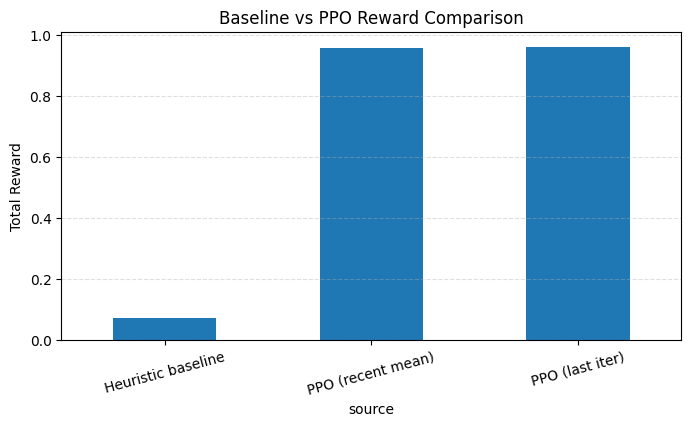

In [6]:
import numpy as np
import pandas as pd

import importlib
import main
importlib.reload(main)
from main import run_episode
del main
from matplotlib import pyplot as plt

def _scalar(info: dict, key: str, default: float = 0.0) -> float:
    raw = info.get(key, default)
    arr = np.asarray(raw)
    if arr.size == 0:
        return float(default)
    return float(arr.reshape(-1)[0])

BASELINE_EPISODES = 100
baseline_env_config = replace(env_config, flatten_observation=False)
baseline_env = SatelliteMACEnv(config=baseline_env_config)
baseline_rng = np.random.default_rng(seed + 4242)
delta_range = int(baseline_env_config.preamble_delta_range)
baseline_records: list[dict[str, float]] = []

for episode_idx in range(BASELINE_EPISODES):
    episode_seed = int(baseline_rng.integers(0, 1_000_000))
    stats, last_info, _ = run_episode(baseline_env, delta_range, baseline_rng, episode_seed,fix=True,fix_acb=0.3)
    requests_cbra = int(round(_scalar(last_info, "requests_cbra", 0.0)))
    requests_pbra = int(round(_scalar(last_info, "requests_pbra", 0.0)))
    ratio_cbra = round(max(0.0, min(_scalar(last_info, "collision_ratio_cbra", 0.0), 1.0)), 4)
    ratio_pbra = round(max(0.0, min(_scalar(last_info, "collision_ratio_pbra", 0.0), 1.0)), 4)
    preamble_counts = last_info.get("preamble_allocation_counts")
    if isinstance(preamble_counts, np.ndarray) and preamble_counts.size == 3:
        preamble_cbra, preamble_pbra, preamble_cfra = map(int, preamble_counts.tolist())
    else:
        allocation = last_info.get("preamble_allocation")
        if isinstance(allocation, np.ndarray) and allocation.size == 3:
            # fallback to ratio * total when counts are unavailable
            ratios = allocation.astype(float)
            total = int(round(np.sum(ratios))) or 64
            preamble_vals = np.maximum(np.round(ratios * total).astype(int), 1)
            preamble_cbra, preamble_pbra, preamble_cfra = preamble_vals.tolist()
        else:
            preamble_cbra = preamble_pbra = 0
            preamble_cfra = 0
    baseline_records.append(
        {
            "episode": episode_idx + 1,
            "steps": stats.steps,
            "total_reward": stats.reward,
            "avg_reward_per_step": stats.reward / max(stats.steps, 1),
            "requests_cbra": requests_cbra,
            "requests_pbra": requests_pbra,
            "collision_ratio_cbra": ratio_cbra,
            "collision_ratio_pbra": ratio_pbra,
            "preamble_cbra": preamble_cbra,
            "preamble_pbra": preamble_pbra,
            "preamble_cfra": preamble_cfra,
        }
    )

baseline_df = pd.DataFrame(baseline_records)

if not baseline_df.empty:
    int_columns = [col for col in ("requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra") if col in baseline_df]
    for column in int_columns:
        baseline_df[column] = baseline_df[column].round().astype(int)
    ratio_columns = [col for col in ("collision_ratio_cbra", "collision_ratio_pbra") if col in baseline_df]
    for column in ratio_columns:
        baseline_df[column] = baseline_df[column].clip(lower=0, upper=1).round(4)

ppo_df = pd.DataFrame(metrics_history) if metrics_history else pd.DataFrame()

if not ppo_df.empty:
    for column in [col for col in ("requests_cbra", "requests_pbra", "preamble_cbra", "preamble_pbra", "preamble_cfra") if col in ppo_df]:
        ppo_df[column] = ppo_df[column].round().astype(int)
    for column in [col for col in ppo_df.columns if col.startswith("collision_ratio")]:
        ppo_df[column] = ppo_df[column].clip(lower=0, upper=1).round(4)

baseline_mean_reward = float(baseline_df["avg_reward_per_step"].mean()) if not baseline_df.empty else float("nan")
ppo_recent_mean = float(ppo_df["reward"].tail(5).mean()) if not ppo_df.empty else float("nan")
ppo_last_reward = float(ppo_df["reward"].iloc[-1]) if not ppo_df.empty else float("nan")

comparison_df = pd.DataFrame(
    [
        {"source": "Heuristic baseline", "reward": baseline_mean_reward},
        {"source": "PPO (recent mean)", "reward": ppo_recent_mean},
        {"source": "PPO (last iter)", "reward": ppo_last_reward},
    ]
)

display(baseline_df)
ax = comparison_df.plot(kind="bar", x="source", y="reward", legend=False, figsize=(8, 4))
ax.set_ylabel("Total Reward")
ax.set_title("Baseline vs PPO Reward Comparison")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.xticks(rotation=15)
comparison_df

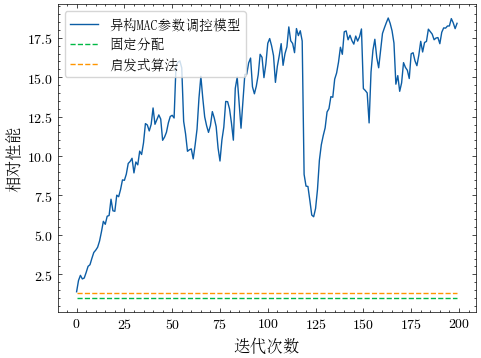

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import pandas as pd
import scienceplots
plt.style.use(['science', 'no-latex'])
font_path = r'C:/Windows/Fonts/simsun.ttc'

my_font = font_manager.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False  # 解决负号 '-' 显示为方块的问题
if not metrics_history:
    raise RuntimeError("metrics_history is empty; run the training cell first.")
# 0	Heuristic baseline
# 0	Heuristic baseline
df = pd.DataFrame(metrics_history)
plot_columns = [col for col in ("reward",) if col in df]
# request_columns = [col for col in ("r_cbra", "r_pbra") if col in df]
if not plot_columns:
    raise RuntimeError("No success_rate/collision_rate columns found in metrics_history.")

fig, ax1 = plt.subplots(figsize=(5.4, 4))
for column in plot_columns:
    ax1.plot(df["iteration"], df[column]/0.052251603646547705, label="异构MAC参数调控模型")
ax1.plot(df["iteration"], 0.052251603646547705 * np.ones_like(df["iteration"])/0.052251603646547705, '--', label='固定分配')
ax1.plot(df["iteration"], 0.06723737327049471 * np.ones_like(df["iteration"])/0.052251603646547705, '--', label='启发式算法')

df["iteration"].shape
ax1.set_xlabel("迭代次数", fontproperties=my_font, fontsize=12) # 建议字号稍微大一点，宋体较细
ax1.set_ylabel("相对性能", fontproperties=my_font, fontsize=12)
# ax1.set_title("Training Success/Collision Rates with Request Load")
ax1.grid(True)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, prop=my_font, loc='best',frameon=True)
plt.grid(False)
plt.savefig("ppo_training_result.svg", bbox_inches='tight')